### AI Usage:

I used AI tools as a supporting resource to generate ideas, understand concepts, and fix small coding errors during my analysis and visualization work. However, all major decisions—including feature selection, data presentation, interpretation, and overall project execution—were completed independently by me.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.shape


(891, 12)

In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
#check missing values
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

## 3.Value counts for key categorical columns

In [18]:
print("\nValue Counts: Survived")
print(df["Survived"].value_counts())



Value Counts: Survived
Survived
0    549
1    342
Name: count, dtype: int64


In [19]:
print("\n Value Counts: Sex ")
print(df["Sex"].value_counts())


 Value Counts: Sex 
Sex
male      577
female    314
Name: count, dtype: int64


In [20]:
print("\nValue Counts: Pclass")
print(df["Pclass"].value_counts())


Value Counts: Pclass
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


## 4) Overall survival rate

In [21]:
overall_survival = df["Survived"].mean() * 100
print("\nOverall Survival Rate:", round(overall_survival, 2), "%")



Overall Survival Rate: 38.38 %


## 5) Survival rate by Sex


--- Survival Rate by Sex (%) ---
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


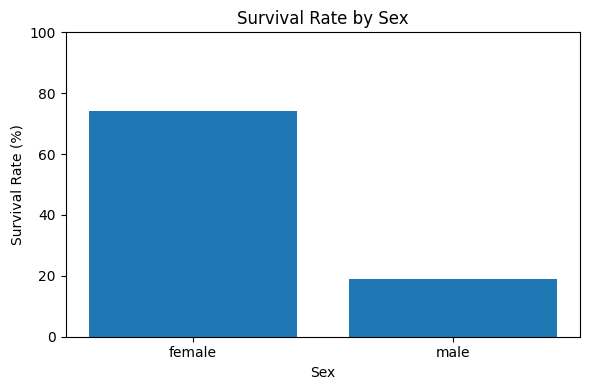

In [22]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
print("\n--- Survival Rate by Sex (%) ---")
print(survival_by_sex)

plt.figure(figsize=(6,4))
plt.bar(survival_by_sex.index, survival_by_sex.values)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


## 6) Survival rate by Pclass


--- Survival Rate by Passenger Class (%) ---
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


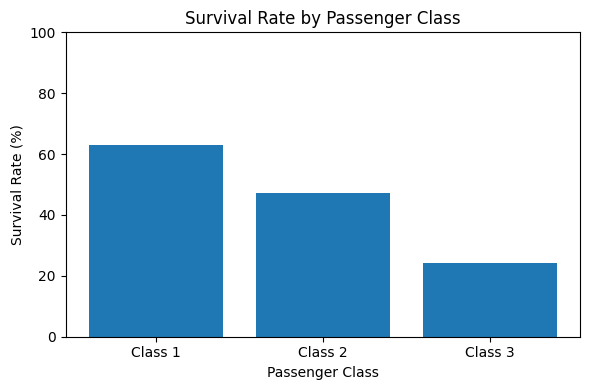

In [23]:
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
print("\n--- Survival Rate by Passenger Class (%) ---")
print(survival_by_class)

plt.figure(figsize=(6,4))
plt.bar(["Class 1", "Class 2", "Class 3"], survival_by_class.values)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 7) Age distribution 

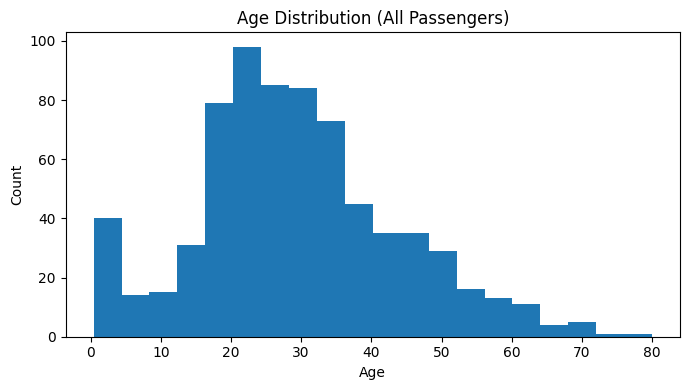

In [24]:
plt.figure(figsize=(7,4))
plt.hist(df["Age"].dropna(), bins=20)
plt.title("Age Distribution (All Passengers)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 8) Age distribution by Survival

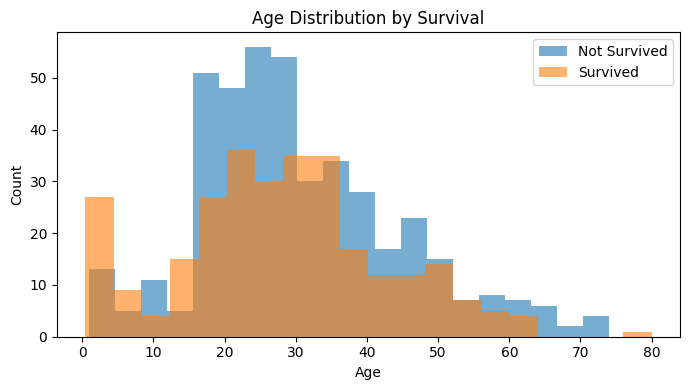

In [25]:
age_survived = df[df["Survived"] == 1]["Age"].dropna()
age_not = df[df["Survived"] == 0]["Age"].dropna()

plt.figure(figsize=(7,4))
plt.hist(age_not, bins=20, alpha=0.6, label="Not Survived")
plt.hist(age_survived, bins=20, alpha=0.6, label="Survived")
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

## 9) Fare distribution

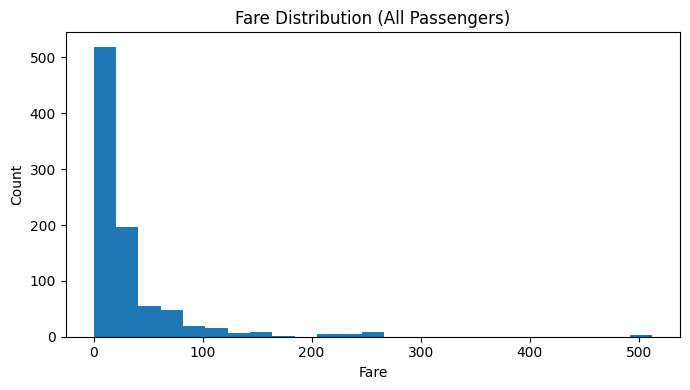

In [26]:
plt.figure(figsize=(7,4))
plt.hist(df["Fare"].dropna(), bins=25)
plt.title("Fare Distribution (All Passengers)")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 10) Fare by Survival

/var/folders/ns/fn6xbd2s2y734n7yhqccmxzc0000gn/T/ipykernel_68935/1984348425.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fare_not, fare_yes], labels=["Not Survived", "Survived"])


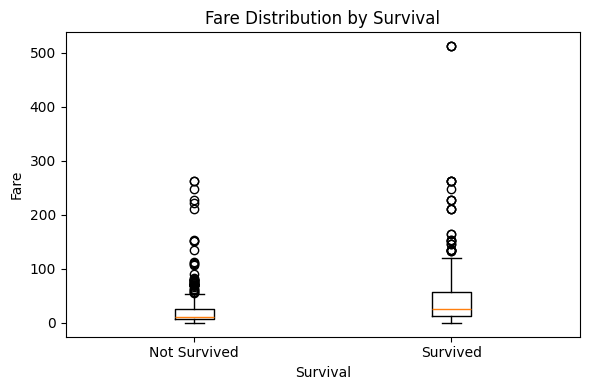

In [27]:
fare_not = df[df["Survived"] == 0]["Fare"].dropna()
fare_yes = df[df["Survived"] == 1]["Fare"].dropna()

plt.figure(figsize=(6,4))
plt.boxplot([fare_not, fare_yes], labels=["Not Survived", "Survived"])
plt.title("Fare Distribution by Survival")
plt.xlabel("Survival")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

## 11) Simple correlation

In [30]:
#Only numeric columns
num_df = df.select_dtypes(include=["int64", "float64"])

print("\n Correlation with Survived (Numeric Only) ")
corr = num_df.corr(numeric_only=True)["Survived"].sort_values(ascending=False)
print(corr)




 Correlation with Survived (Numeric Only) 
Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64


### GOOD VISUALIZATION 1


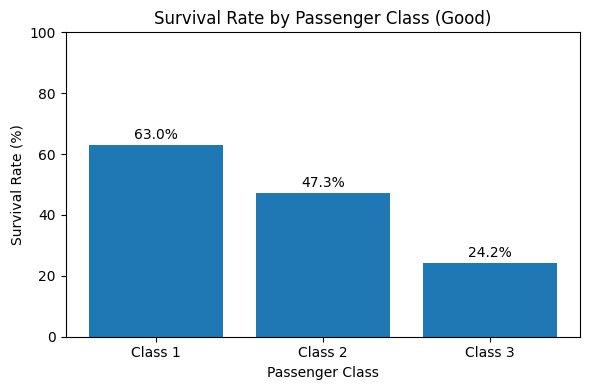

In [32]:
survival_class = df.groupby("Pclass")["Survived"].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(["Class 1", "Class 2", "Class 3"], survival_class.values)

plt.title("Survival Rate by Passenger Class (Good)")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, v in enumerate(survival_class.values):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

Survival Rate by Passenger Class (Bar Graph)

The bar graph above displays the survival rate of each passenger class using percentages. The y-axis starts from 0 and ends at 100, which is useful in showing the exact survival rate of each class.

The bar graph above is very effective in showing that First Class passengers had the highest survival rate, followed by Second Class, and then Third Class. This graph is useful because it uses percentages instead of actual figures, which is useful in making a comparison even though each class had a different number of passengers.

This graph is ethical because:

It shows data for all passengers.

It uses a whole y-axis scale (0-100%).

It does not overstate differences.

It uses clear labels.

### GOOD VISUALIZATION 2 (Pie Chart - Ethical)


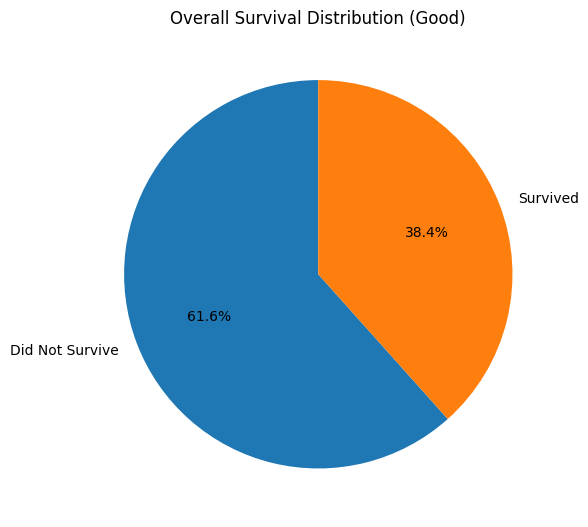

In [36]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    survival_counts.values,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Survival Distribution (Good)")
plt.tight_layout()
plt.show()

Overall Survival Distribution (Pie Chart)

The pie chart illustrates the overall survival rate of the passengers, distinguishing between those who survived and those who did not. It displays the entire dataset, along with the actual percentages.

The chart effectively conveys the message that the majority of the passengers did not survive, which is historically accurate. It is easy to understand due to the labels and percentages.

This is an ethical visualization because:

It utilizes the entire data.

It displays accurate percentages.

It does not favor one group.

It conveys the message in a simple way.

### BAD VISUALIZATION 1 (Bar Graph - Misleading)


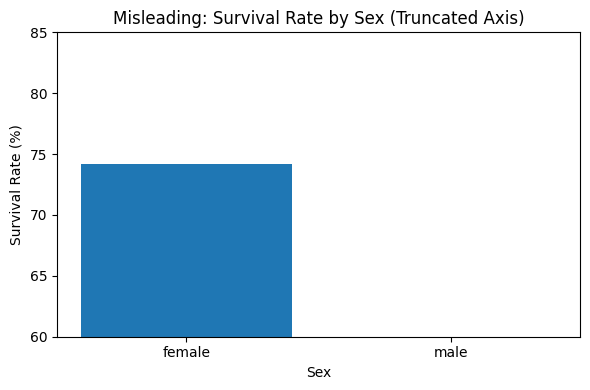

In [38]:
survival_sex = df.groupby("Sex")["Survived"].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(survival_sex.index, survival_sex.values)

plt.title("Misleading: Survival Rate by Sex (Truncated Axis)")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")

# Misleading zoom
plt.ylim(60, 85)

plt.tight_layout()
plt.show()



Truncated Y-Axis (Bar Graph Manipulation)
This bar chart is a deliberate attempt at manipulating the y-axis, which is truncated at 60. Although the real survival rate difference between men and women exists, the truncated y-axis is an attempt at visual manipulation, creating an impression of a greater difference in survival rates between the genders.
By zooming in on a small section, the bars appear to be quite different in height, when in reality, the difference in the percentage is not quite as significant.
This is an example of how the use of visual manipulation can deceive the reader, without the actual data changing.

### BAD VISUALIZATION 2 (Pie Chart - Misleading)


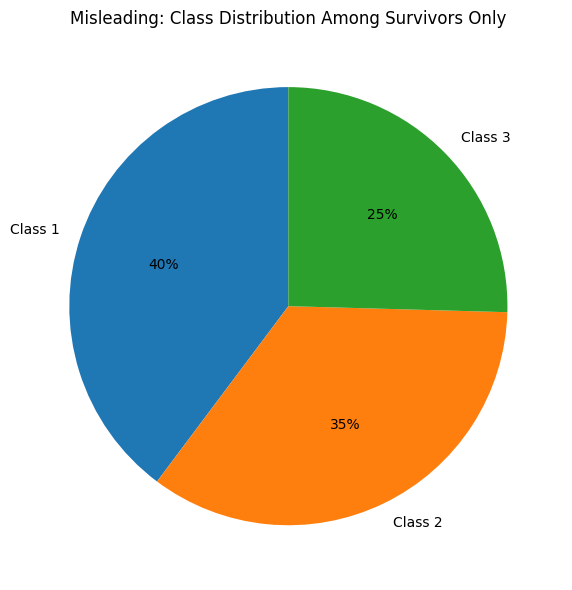

In [40]:
only_survivors = df[df["Survived"] == 1]
class_counts = only_survivors["Pclass"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    class_counts.values,
    labels=["Class 1", "Class 2", "Class 3"],
    autopct="%1.0f%%",
    startangle=90
)

plt.title("Misleading: Class Distribution Among Survivors Only")
plt.tight_layout()
plt.show()

Cherry-Picked Pie Chart (Only Survivors)

The pie chart only displays the distribution of the passenger classes among the survivors. Although the information is accurate, it fails to highlight that many passengers in the different classes did not survive.

The pie chart only displays the information about the survivors, giving a misleading impression that the survival rates of some classes were exceptionally high. Nevertheless, it fails to consider the total number of passengers in each class.

The pie chart is misleading for several reasons:

It does not include non-survivors.

It displays cherry-picked information.

It may provide misleading information about the survival rates.